В цьому домашньому завданні ми з вами побудуємо повноцінне ML-рішення реальної ML-задачі. Ви вже маєте всі знання, які для цього потрібні. Дотримуйтесь інструкцій, та користуйтесь матеріалами лекцій, аби виконувати завдання. Тут інструкції будуть детальні, а в подільших завданнях - будуть ставати все менш детальними, аби ви вже починали самостійно структурувати ML-проєкт і до кінця курсу для вас розвʼязати будь-яку ML–задачу було eazy-breezy.

## Dataset

Будемо працювати з набором даних `cars.csv`, який описує автомобілі і їх ціну у індійських рупіях :) Мета - передбачити ціну авто за його характеристиками. Опис набору даних:

| Назва рядка            | Опис                                                                                                                                                 |
|------------------------|--------------------------------------------------------------------------------------------------------------------------------------------------------|
| Car_ID                 | Унікальний ідентифікатор для кожного оголошення про автомобіль.                                                                                         |
| Brand                  | Бренд або виробник автомобіля (наприклад, Toyota, Honda, Ford тощо).                                                                                     |
| Model                  | Модель автомобіля (наприклад, Camry, Civic, Mustang тощо).                                                                                               |
| Year                   | Рік виготовлення автомобіля.                                                                                                                            |
| Kilometers_Driven      | Загальний пробіг автомобіля у кілометрах.                                                                                                               |
| Fuel_Type              | Тип палива, який використовує автомобіль (наприклад, бензин, дизель, електро тощо).                                                                      |
| Transmission           | Тип трансмісії автомобіля (наприклад, механічна, автоматична).                                                                                           |
| Owner_Type             | Кількість попередніх власників автомобіля (наприклад, перший, другий, третій).                                                                           |
| Mileage                | Паливна ефективність автомобіля у кілометрах на літр.                                                                                                   |
| Engine                 | Об'єм двигуна автомобіля в кубічних сантиметрах (CC).                                                                                                   |
| Power                  | Максимальна потужність автомобіля в кінських силах (bhp).                                                                                               |
| Seats                  | Кількість місць в автомобілі.                                                                                                                           |
| Price                  | Вартість автомобіля в INR (індійські рупії), що є цільовою змінною для прогнозування.                                                                   |

# Імпорти

Для зручності рекомендую всі імпорти розмістити тут нагорі, аби коли ви перезавантажували ноутбук, одразу можна було в один запуск клітинки імпортувати всі потрібні бібліотеки.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression
from sklearn.metrics import root_mean_squared_error
from sklearn.model_selection import train_test_split
import statsmodels.api as sm
import seaborn as sns
from sklearn import preprocessing as pr
import plotly.express as px
import plotly.graph_objects as go

pd.set_option('float_format', '{:.2f}'.format)

# Знайомство з даними

**Завдання 1.** Завантажте набір даних `cars.csv` в pandas.DataFrame. Виведіть перші 5 записів.

In [2]:
cars_df = pd.read_csv('cars.csv')
cars_df.head()

,Car_ID,Brand,Model,Year,Kilometers_Driven,Fuel_Type,Transmission,Owner_Type,Mileage,Engine,Power,Seats,Price
0,1,Toyota,Corolla,2018,50000,Petrol,Manual,First,15,1498,108,5,800000
1,2,Honda,Civic,2019,40000,Petrol,Automatic,Second,17,1597,140,5,1000000
2,3,Ford,Mustang,2017,20000,Petrol,Automatic,First,10,4951,395,4,2500000
3,4,Maruti,Swift,2020,30000,Diesel,Manual,Third,23,1248,74,5,600000
4,5,Hyundai,Sonata,2016,60000,Diesel,Automatic,Second,18,1999,194,5,850000


**Завдання 2.** Виведіть типи даних колонок даних, а також дослідіть, які по факту типи даних мають записи в кожній колонці (тип `object` може містити різні типи даних) і скільки значень є в кожній категоріальній колонці.

Напишіть висновок, скільки в наборі даних числових та категоріальних колонок кожного з трьох різних типів (бінарна, мільтикатегоріальна без порядку, мультикатегоріальна з порядком). Шаблон висновку

```
В наборі даних 10 числових і 10 категоріальних колонок з них
- 2 бінарні (мають лише 2 значення)
- 6 мультикатегоріальних (більше 2х значень) зі значеннями, для яких немає відношення порядку
- 2 колонки, в яких можна встановити відношення порядку (наприклад Small<Medium<Large)
```

Якщо не знаєте, як це зробити з `pandas` - ось підказка, які методи можуть допомогти вам виконати це завдання

- pandas.DataFrame.info()
- pandas.DataFrame.dtypes
- pandas.DataFrame.loc[...]
- pandas.DataFrame.select_dtypes(...)
- pandas.Series.unique()
- pandas.Series.nunique()

Детальніше ознайомитись з кожним ви можете в [документації](https://pandas.pydata.org/docs/reference/frame.html), або написати в окремій клітинці знак питання і назву методу (тільки приберіть це перед здачею, бо перегляд документації - не допомагає зрозуміти дані і хід думок, а Ваша робота - це як презентація замовнику зробленої задачі).


In [3]:
cars_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100 entries, 0 to 99
Data columns (total 13 columns):
 #   Column             Non-Null Count  Dtype 
---  ------             --------------  ----- 
 0   Car_ID             100 non-null    int64 
 1   Brand              100 non-null    object
 2   Model              100 non-null    object
 3   Year               100 non-null    int64 
 4   Kilometers_Driven  100 non-null    int64 
 5   Fuel_Type          100 non-null    object
 6   Transmission       100 non-null    object
 7   Owner_Type         100 non-null    object
 8   Mileage            100 non-null    int64 
 9   Engine             100 non-null    int64 
 10  Power              100 non-null    int64 
 11  Seats              100 non-null    int64 
 12  Price              100 non-null    int64 
dtypes: int64(8), object(5)
memory usage: 10.3+ KB


In [4]:
for col in cars_df.columns[cars_df.dtypes == 'object']:
  print(col, cars_df[col].unique(), cars_df[col].nunique())

Brand ['Toyota' 'Honda' 'Ford' 'Maruti' 'Hyundai' 'Tata' 'Mahindra' 'Volkswagen'
 'Audi' 'BMW' 'Mercedes'] 11
Model ['Corolla' 'Civic' 'Mustang' 'Swift' 'Sonata' 'Nexon' 'Scorpio' 'Polo'
 'A4' 'X1' 'C-Class' 'Endeavour' 'Creta' 'Harrier' 'Ertiga' 'City'
 'Tiguan' 'Q3' '5 Series' 'GLC' 'Innova' 'Figo' 'Verna' 'Altroz' 'Thar'
 'Passat' 'A6' 'X3' 'E-Class' 'Fortuner' 'Aspire' 'Elantra' 'Safari'
 'Vitara' 'WR-V' 'Ameo' 'A3' '7 Series' 'GLE' 'Yaris' 'Ranger' 'Santro'
 'Tigor' 'S-Cross' 'BR-V' 'T-Roc' 'Q7' 'X5' 'GLA' 'Camry' 'Venue' 'Tiago'
 'XUV300' 'Vento' 'A5' '3 Series' 'Innova Crysta' 'EcoSport'] 58
Fuel_Type ['Petrol' 'Diesel'] 2
Transmission ['Manual' 'Automatic'] 2
Owner_Type ['First' 'Second' 'Third'] 3


In [5]:
len(cars_df.select_dtypes(include="object").columns)

5

In [6]:
cars_df.describe()

,Car_ID,Year,Kilometers_Driven,Mileage,Engine,Power,Seats,Price
count,100.00,100.00,100.00,100.00,100.00,100.00,100.00,100.00
mean,50.50,2018.39,28150.00,17.21,1855.23,158.13,5.23,1574000.00
std,29.01,1.17,9121.38,3.31,631.31,76.97,0.75,1000264.61
min,1.00,2016.00,10000.00,10.00,999.00,68.00,4.00,450000.00
25%,25.75,2017.75,22000.00,15.00,1462.00,103.00,5.00,700000.00
50%,50.50,2018.00,27000.00,17.00,1774.00,148.00,5.00,1300000.00
75%,75.25,2019.00,32000.00,19.00,2143.00,187.00,5.00,2500000.00
max,100.00,2021.00,60000.00,25.00,4951.00,396.00,7.00,4000000.00


В наборі даних 8 числових і 5 категоріальних колонок з них
- 2 бінарні (мають лише 2 значення): Fuel_Type, Transmission
- 2 мультикатегоріальних (більше 2х значень) зі значеннями, для яких немає відношення порядку: Brand, Model
- 1 колонка, в якій можна встановити відношення порядку (наприклад Small<Medium<Large): Owner_Type

**Завдання 3**. Розділіть дані на тренувальні і тест. Відведіть в тест 20%, поставте `random_state=12`. Ми будемо передбачати колонку `Price` - тож, вона є цільовою змінною. В результаті у Вас має бути 4 набори даних `X_train, X_test, y_train, y_test`.

Надалі ми всюди тренуємо методи для кодування, масштабування та саму модель тільки на тренувальних даних X_train (та y_train для моделі), а на тестувальних лише використовуємо вже навчені методи для кодування, масштабування і модель викликаючи в них `transform()` (для методів обробки даних) або `predict()` (для моделі).

І так само треба робити завжди.

In [58]:
target = cars_df.Price
inputs = cars_df[cars_df.columns.drop('Price')]

X_train, X_test, y_train, y_test = train_test_split(inputs, target, test_size=0.2, random_state=12)

In [59]:
display(X_train.describe(), X_test.describe())

,Car_ID,Year,Kilometers_Driven,Mileage,Engine,Power,Seats
count,80.00,80.00,80.00,80.00,80.00,80.00,80.00
mean,53.16,2018.36,28362.50,17.06,1910.74,166.89,5.22
std,28.45,1.13,9227.43,3.43,660.86,81.94,0.75
min,1.00,2016.00,10000.00,10.00,1047.00,68.00,4.00
25%,30.75,2018.00,22000.00,15.00,1487.50,103.00,5.00
50%,53.50,2018.00,28000.00,17.00,1950.00,154.00,5.00
75%,77.25,2019.00,32750.00,19.00,2187.50,191.00,5.00
max,100.00,2021.00,60000.00,25.00,4951.00,396.00,7.00


,Car_ID,Year,Kilometers_Driven,Mileage,Engine,Power,Seats
count,20.00,20.00,20.00,20.00,20.00,20.00,20.00
mean,39.85,2018.50,27300.00,17.80,1633.20,123.10,5.25
std,29.53,1.36,8862.10,2.76,442.65,36.58,0.79
min,8.00,2016.00,10000.00,13.00,999.00,68.00,4.00
25%,15.75,2017.00,21500.00,16.75,1345.50,97.00,5.00
50%,28.50,2019.00,26000.00,17.50,1497.50,113.00,5.00
75%,63.00,2019.25,32000.00,19.25,1968.00,148.50,5.00
max,93.00,2021.00,42000.00,25.00,2755.00,190.00,7.00


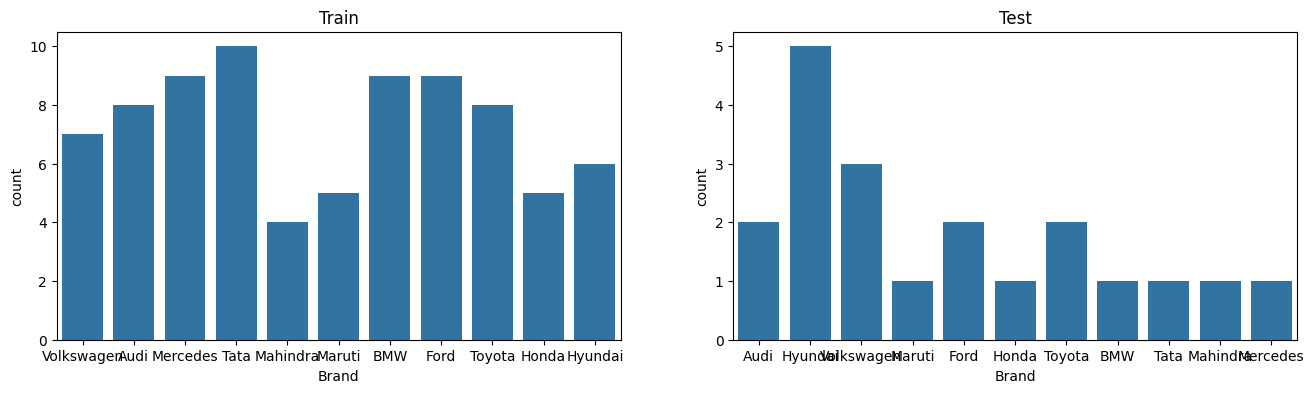

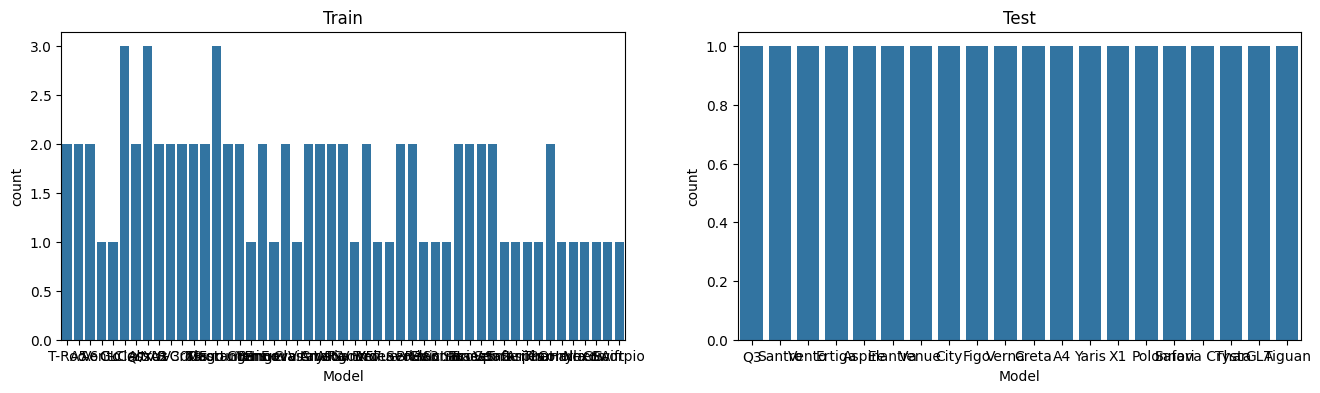

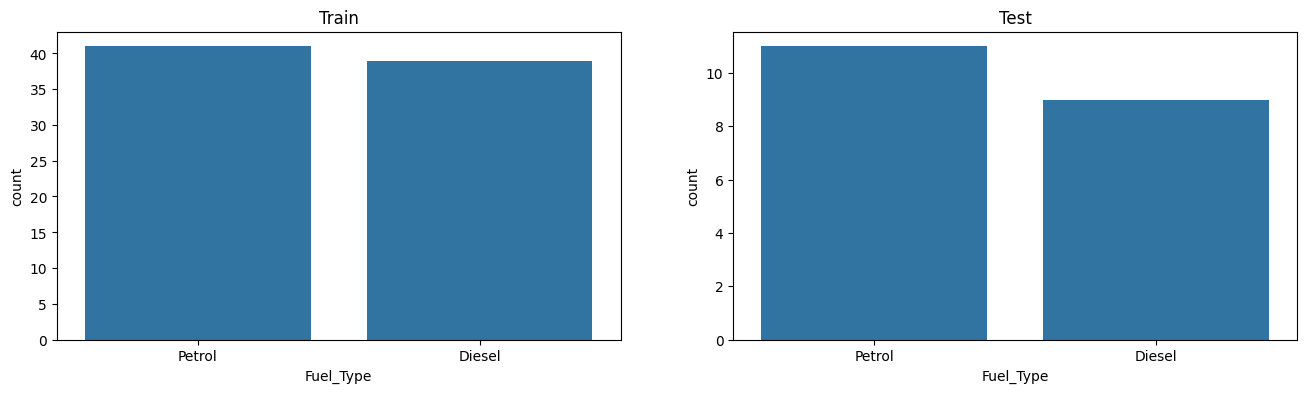

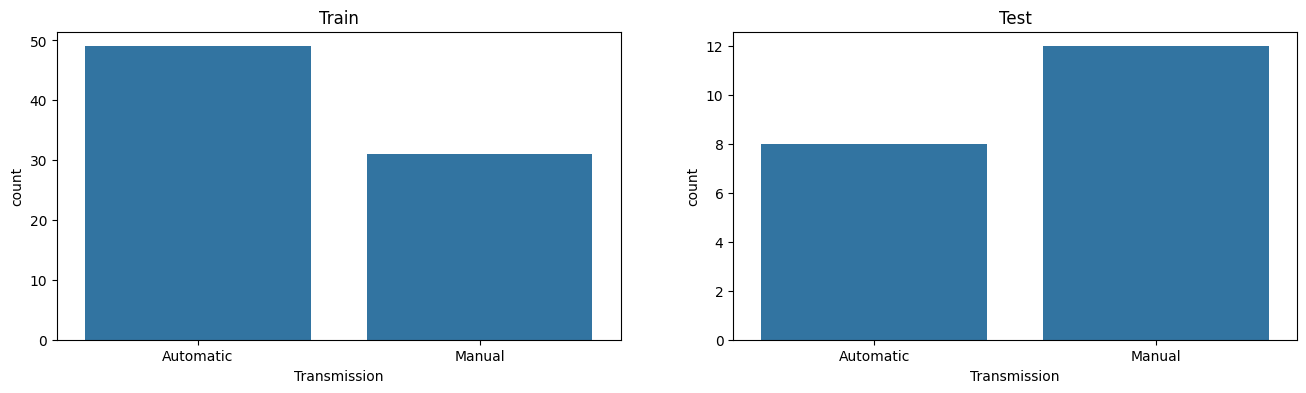

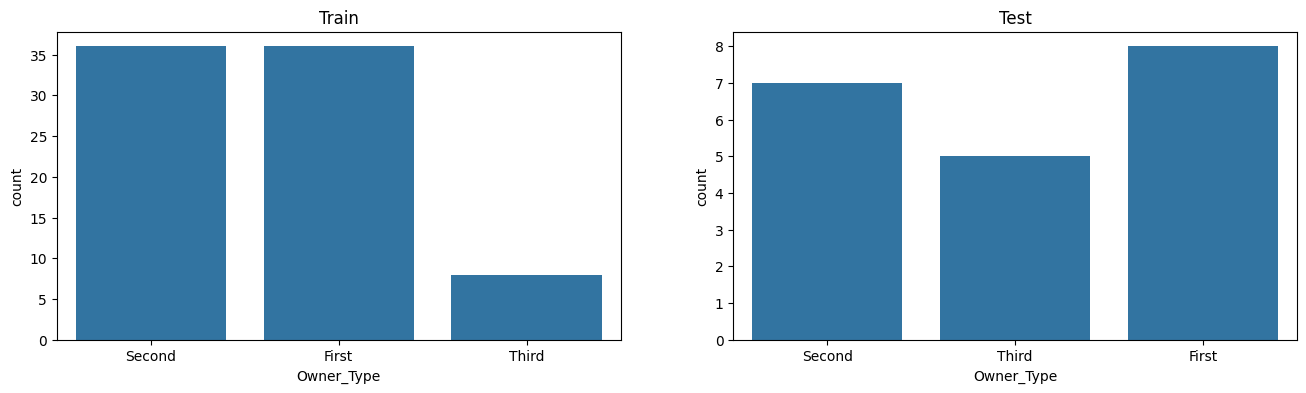

In [66]:
for col in cars_df.select_dtypes(include='object').columns:
  fig, axes = plt.subplots(1, 2, figsize=(16, 4))
  sns.countplot(x=X_train[col], ax=axes[0])
  axes[0].set_title("Train")

  sns.countplot(x=X_test[col], ax=axes[1])
  axes[1].set_title("Test")

  plt.show()

**Завдання 4**. Кодуємо категоріальні колонки.

1. Закодуйте колонки з бінарними значеннями `Fuel_Type` і `Transmission` так, аби вони були у чисельному представленні і містили лише 0 так 1. Приклад був у лекції. Значення 1 нехай буде у категорії, яка містить більше значень в колонці.

2. Закодуйте колонку `Brand` з використанням `sklearn.preprocessing.OneHotEncoder` аналогічно до того, як ми робили це в лекції. Увага! Ми робимо виклик методу `Encoder.fit()` на тренувальних даних `X_train`, а на тестувальних тільки викликаємо `Encoder.transform()`. Додайте закодовані значення в набори даних `X_train`, `X_test`.

3. Колонку `Owner_Type` з використанням `sklearn.preprocessing.OrdinalEncoder` я закодую для вас. Проаналізуйте, що відбувається.

Колонка `Model` містять забагато значень для кодування в тому вигляді, як вона є зараз, з огляду на невелику кількість даних. Якщо ви бачите, як можна згрупувати значення в цій колонці скоротивши кількість унікальних значень до 3-5, то можете виконати ще цю трансформацію, використати цю колонку в моделі і отримати додаткову практику і бал, якщо все буде зроблено правильно. А якщо неправильно - то фідбек на Вашу роботу :)

In [8]:
# encoding Fuel_Type
cars_df.Fuel_Type.value_counts()

,count
Fuel_Type,
Petrol,52
Diesel,48


In [9]:
fuel_type_codes = {'Petrol': 1, 'Diesel': 0}
X_train['fuel_type_codes'] = X_train.Fuel_Type.map(fuel_type_codes)
X_test['fuel_type_codes'] = X_test.Fuel_Type.map(fuel_type_codes)

In [10]:
# encoding Transmission
cars_df.Transmission.value_counts()

,count
Transmission,
Automatic,57
Manual,43


In [11]:
transmission_codes = {'Manual': 0, 'Automatic': 1}
X_train['transmission_codes'] = X_train.Transmission.map(transmission_codes)
X_test['transmission_codes'] = X_test.Transmission.map(transmission_codes)

display(X_train.head(), X_test.head())

,Car_ID,Brand,Model,Year,Kilometers_Driven,Fuel_Type,Transmission,Owner_Type,Mileage,Engine,Power,Seats,fuel_type_codes,transmission_codes
83,84,Volkswagen,T-Roc,2019,22000,Petrol,Automatic,Second,18,1498,148,5,1,1
55,56,Audi,A5,2018,28000,Diesel,Automatic,First,17,1968,187,5,0,1
26,27,Audi,A6,2018,28000,Petrol,Automatic,First,15,1984,241,5,1,1
54,55,Volkswagen,Vento,2017,32000,Petrol,Manual,Second,18,1598,103,5,1,0
19,20,Mercedes,GLC,2017,26000,Petrol,Automatic,Second,12,1991,241,5,1,1


,Car_ID,Brand,Model,Year,Kilometers_Driven,Fuel_Type,Transmission,Owner_Type,Mileage,Engine,Power,Seats,fuel_type_codes,transmission_codes
17,18,Audi,Q3,2016,38000,Petrol,Automatic,Second,15,1395,148,5,1,1
41,42,Hyundai,Santro,2019,26000,Petrol,Manual,Third,20,1086,68,5,1,0
92,93,Volkswagen,Vento,2017,32000,Petrol,Manual,Second,18,1598,103,5,1,0
14,15,Maruti,Ertiga,2020,18000,Petrol,Manual,First,19,1462,103,7,1,0
68,69,Ford,Aspire,2019,26000,Petrol,Manual,Third,20,1194,94,5,1,0


<Axes: xlabel='Brand', ylabel='Price'>

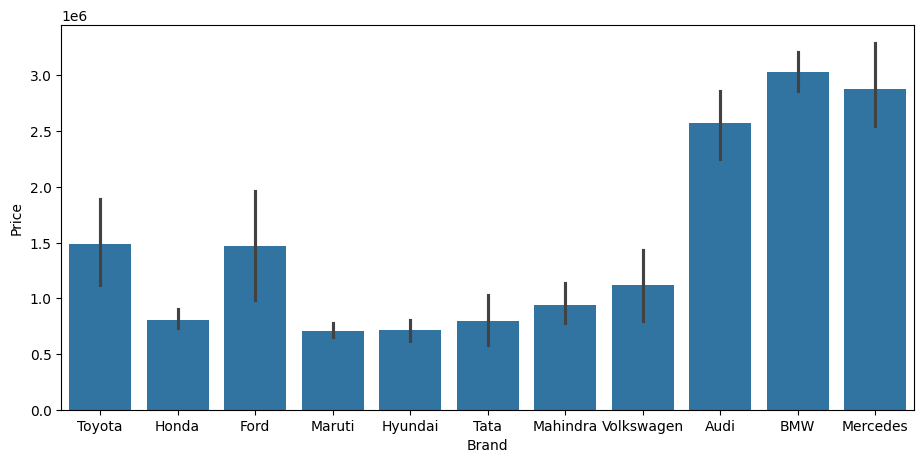

In [12]:
# look at Brands
plt.figure(figsize=(11,5))
sns.barplot(data=cars_df, x='Brand', y='Price')

In [15]:
# encoding Brand
oh_enc = pr.OneHotEncoder().fit(X_train[['Brand']])
oh_enc.categories_

[array(['Audi', 'BMW', 'Ford', 'Honda', 'Hyundai', 'Mahindra', 'Maruti',
        'Mercedes', 'Tata', 'Toyota', 'Volkswagen'], dtype=object)]

In [16]:
one_hot_brand_train = oh_enc.transform(X_train[['Brand']]).toarray()
one_hot_brand_test = oh_enc.transform(X_test[['Brand']]).toarray()

# enter encoded Brand into datasets
X_train[oh_enc.categories_[0]] = one_hot_brand_train
X_test[oh_enc.categories_[0]] = one_hot_brand_test

In [ ]:
# cars_df[['Brand','Model']].drop_duplicates().sort_values('Brand')

,Brand,Model
36,Audi,A3
26,Audi,A6
46,Audi,Q7
17,Audi,Q3
55,Audi,A5
8,Audi,A4
27,BMW,X3
47,BMW,X5
37,BMW,7 Series
18,BMW,5 Series


In [17]:
# encodeing Models - make shorter list of models
def model_grouped(model):
  if model.startswith('X') and len(model) == 2:
    model = 'X series'
  elif model.startswith('A') and len(model) == 2:
    model = 'A series'
  elif model.startswith('Q') and len(model) == 2:
    model = 'Q series'
  elif model.endswith(' Series'):
    model = 'Num series'
  elif model.startswith('GL') and len(model) == 3:
    model = 'GL series'
  elif model.endswith('-Class'):
    model = 'Class series'
  else:
    model = 'Name series'
  return model

X_train['Model_grouped'] = X_train.Model.apply(model_grouped)
X_test['Model_grouped'] = X_test.Model.apply(model_grouped)

X_train.Model_grouped.nunique()

7

In [19]:
# encoding Model - one-hot encode shorter list of models
oh_enc = pr.OneHotEncoder().fit(X_train[['Model_grouped']])

one_hot_model_train = oh_enc.transform(X_train[['Model_grouped']]).toarray()
one_hot_model_test = oh_enc.transform(X_test[['Model_grouped']]).toarray()

# enter encoded models into datasets
X_train[oh_enc.categories_[0]] = one_hot_model_train
X_test[oh_enc.categories_[0]] = one_hot_model_test

In [20]:
# encode Owner_Type as an ordered column
ordenc = pr.OrdinalEncoder(categories=[['First', 'Second', 'Third']]) # визначаємо порядок категорій
ordenc.fit(X_train[['Owner_Type']])

# enter encoded models into datasets
X_train['Owner_Type_Codes'] = ordenc.transform(X_train[['Owner_Type']])
X_test['Owner_Type_Codes'] = ordenc.transform(X_test[['Owner_Type']])

Очікуваний результат після трансформацій:

In [24]:
# make train dataset with number only columns (after encoding finished)
X_train = X_train.drop(X_train.select_dtypes("object").columns, axis=1)

In [23]:
# make test dataset with number only columns (after encoding finished)
X_test = X_test.drop(X_test.select_dtypes("object").columns, axis=1)

In [25]:
pd.set_option('display.max_columns', 100)
display(X_train.head()), display(X_test.head())

,Car_ID,Year,Kilometers_Driven,Mileage,Engine,Power,Seats,fuel_type_codes,transmission_codes,Audi,BMW,Ford,Honda,Hyundai,Mahindra,Maruti,Mercedes,Tata,Toyota,Volkswagen,A series,Class series,GL series,Name series,Num series,Q series,X series,Owner_Type_Codes
83,84,2019,22000,18,1498,148,5,1,1,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,1.00,0.00,0.00,0.00,1.00,0.00,0.00,0.00,1.00
55,56,2018,28000,17,1968,187,5,0,1,1.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,1.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00
26,27,2018,28000,15,1984,241,5,1,1,1.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,1.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00
54,55,2017,32000,18,1598,103,5,1,0,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,1.00,0.00,0.00,0.00,1.00,0.00,0.00,0.00,1.00
19,20,2017,26000,12,1991,241,5,1,1,0.00,0.00,0.00,0.00,0.00,0.00,0.00,1.00,0.00,0.00,0.00,0.00,0.00,1.00,0.00,0.00,0.00,0.00,1.00


,Car_ID,Year,Kilometers_Driven,Mileage,Engine,Power,Seats,fuel_type_codes,transmission_codes,Audi,BMW,Ford,Honda,Hyundai,Mahindra,Maruti,Mercedes,Tata,Toyota,Volkswagen,A series,Class series,GL series,Name series,Num series,Q series,X series,Owner_Type_Codes
17,18,2016,38000,15,1395,148,5,1,1,1.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,1.00,0.00,1.00
41,42,2019,26000,20,1086,68,5,1,0,0.00,0.00,0.00,0.00,1.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,1.00,0.00,0.00,0.00,2.00
92,93,2017,32000,18,1598,103,5,1,0,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,1.00,0.00,0.00,0.00,1.00,0.00,0.00,0.00,1.00
14,15,2020,18000,19,1462,103,7,1,0,0.00,0.00,0.00,0.00,0.00,0.00,1.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,1.00,0.00,0.00,0.00,0.00
68,69,2019,26000,20,1194,94,5,1,0,0.00,0.00,1.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,1.00,0.00,0.00,0.00,2.00


(None, None)

**Завдання 5.** Оберіть лише числові колонки з `X_train` (можна для цього використати `pandas.select_dtypes(...)` або видалити всі НЕчислові дані, вони нам вже не потрібні), обʼєднайте ці дані з `y_train` (зручно з `pandas.concat([df1, df2], axis=1)`), побудуйте для цих даних матрицю кореляції і проаналізуйте її. Напишіть висновок, які колонки корелюють з цільовою змінною на більш ніж 0.5 за модулем (може бути як позитивна, так і негативна кореляція).

In [26]:
# make the general encoded train dataset with input and target
Xy_train = pd.concat([X_train, y_train], axis=1)
Xy_train.head()

,Car_ID,Year,Kilometers_Driven,Mileage,Engine,Power,Seats,fuel_type_codes,transmission_codes,Audi,BMW,Ford,Honda,Hyundai,Mahindra,Maruti,Mercedes,Tata,Toyota,Volkswagen,A series,Class series,GL series,Name series,Num series,Q series,X series,Owner_Type_Codes,Price
83,84,2019,22000,18,1498,148,5,1,1,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,1.00,0.00,0.00,0.00,1.00,0.00,0.00,0.00,1.00,1600000
55,56,2018,28000,17,1968,187,5,0,1,1.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,1.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,2600000
26,27,2018,28000,15,1984,241,5,1,1,1.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,1.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,3200000
54,55,2017,32000,18,1598,103,5,1,0,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,1.00,0.00,0.00,0.00,1.00,0.00,0.00,0.00,1.00,650000
19,20,2017,26000,12,1991,241,5,1,1,0.00,0.00,0.00,0.00,0.00,0.00,0.00,1.00,0.00,0.00,0.00,0.00,0.00,1.00,0.00,0.00,0.00,0.00,1.00,2500000


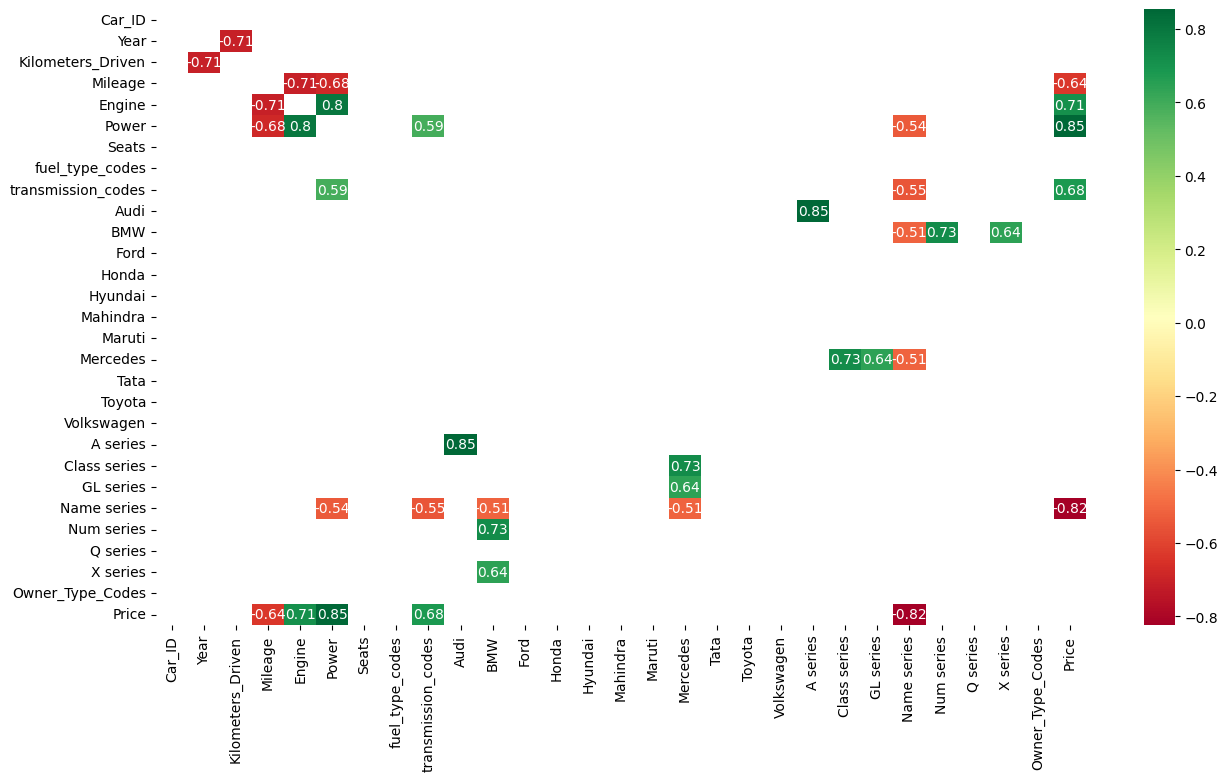

In [27]:
# look at correlations in new train dataset
corr = Xy_train.corr()
plt.figure(figsize=(15,8))
sns.heatmap(data=corr[((corr >= 0.5) & (corr < 0.9999)) | (corr <= -0.5)], annot = True, cmap = "RdYlGn", cbar = True)
plt.show()

З цільовою змінною найбільше корелюють(>0.5 <-0.5) колонки Mileage/Name series - негативно, Engine/Power/Transmission(transmission_codes) - позитивно. Тобто їхнє значення найбільше за усіх впливає на ціну авто. Такі колонки і варто використовувати в моделі, щоб отримати кращі результати.

**Завдання 6**. Тренуємо лінійну регресію.
0. Видаліть усі НЕчислові колонки з `X_train`, `X_test`, якщо ще цього не зробили.
1. Натренуйте лінійну регресую з `sklearn` на усіх числових даних тренувального набору `X_train`.
2. Зробіть передбачення на  `X_train`, `X_test`. Знайдіть і виведіть root mean squared error відхилення передбачення від справжніх значень цільової змінної.
3. Побудуйте графік розсіювання передбачень проти реальних даних цільової змінної для тренувального і тестувального наборів даних. Що можете сказати про якість моделі?

In [28]:
# build first linear regression on train dataset
lin_reg = LinearRegression().fit(X_train, y_train)

# make predictions by trained model for train and test datasets
pred_train = lin_reg.predict(X_train)
pred_test = lin_reg.predict(X_test)

# calculate rmse for both train and test predictions
rmse_train = root_mean_squared_error(y_train, pred_train)
rmse_test = root_mean_squared_error(y_test, pred_test)
display(rmse_train, rmse_test)

206002.07007584622

255364.25235767628

In [29]:
# look at scetterplot for real and predicted values for Train and Test datasets to evaluate the accuracy
fig = px.scatter(x=y_train, y=pred_train, title='Y real vs. Y predicted TRAIN',labels={'x':'Y real', 'y':'Y predicted'})
fig.add_trace(go.Scatter(x=y_train, y=y_train, mode='lines', name='ideal', line=dict(color='yellow')))
fig.update_traces(marker_size=5)
fig.show()

In [30]:
fig = px.scatter(x=y_test, y=pred_test, title='Y real vs. Y predicted TEST',labels={'x':'Y real', 'y':'Y predicted'})
fig.add_trace(go.Scatter(x=y_test, y=y_test, mode='lines', name='ideal', line=dict(color='yellow')))
fig.update_traces(marker_size=5)
fig.show()

За графіками розсіювання можна зробити висновок (як і за RMSE), що передбачення для тестового набору менш точні, ніж для тренувального - очікувано). Сильних викидів ніде не спостерігається, і точки більш-менш рівномірно розподілені навкого діагоналі. Однак розташовані доволі розлого навколо діагоналі і є куди покращувати модель.

**Завдання 7**. Ми хочемо проаналізувати як впливає кожен чинник на цілову змінну. Для цього давайте промасштабуємо наші дані.
1. Зробіть масштабування незалежних змінних використовуючи `StandardScaler`. Тренуємо на тренувальних даних, а на тестувальних лише викликаємо `transform`.

2. Натренуйте модель на відмасштабованих даних і перегляньте коефіцієнти моделі. Які колонки є найвпливовішими на формування передбачення з точки зору коефіцієнтів? Проаналізуйте напрям дії найважливіших коефіцієнтів. Чи це логічно з точки зору значення відповідних змінних, що вони впливають на цільову змінну саме в напрямі збільшення / зменшення?

In [31]:
# look at the weights and intercept for the first model
lin_reg.coef_, lin_reg.intercept_

(array([ 2.01528885e+02, -1.24203707e+04, -1.10140482e+01, -3.36392579e+04,
        -4.56700164e+00,  6.25556329e+03,  2.68447510e+04, -3.63453047e+05,
         2.21955716e+05,  1.83428962e+05,  2.02985419e+05, -1.04745812e+05,
        -6.78789908e+03, -2.96728834e+05, -3.70427225e+05, -1.77324563e+05,
         2.22791982e+05,  8.73366261e+04,  3.03759069e+05, -4.42877248e+04,
         2.35989268e+05,  1.22990550e+05,  9.98014313e+04, -6.09206362e+05,
         1.84965258e+05, -5.25603060e+04,  1.80201605e+04,  7.56939063e+04]),
 np.float64(26780157.577654008))

In [32]:
# look at weights for each column to check the influence
weights_df = pd.DataFrame({
    'feature': np.append(X_train.columns, 1),
    'weight': np.append(lin_reg.coef_, lin_reg.intercept_)
})
weights_df.sort_values('weight', ascending=False)

,feature,weight
28,1,26780157.58
18,Toyota,303759.07
20,A series,235989.27
16,Mercedes,222791.98
8,transmission_codes,221955.72
10,BMW,202985.42
24,Num series,184965.26
9,Audi,183428.96
21,Class series,122990.55
22,GL series,99801.43


In [41]:
# make the list of numerical input columns from the base dataset (to get actually numerical and not encoded columns)
num_columns = cars_df.select_dtypes(exclude='object').drop('Price', axis=1).columns

# train scaler on the train dataset
scaler = pr.StandardScaler().fit(X_train[num_columns])

scaler.mean_, scaler.var_

(array([5.3162500e+01, 2.0183625e+03, 2.8362500e+04, 1.7062500e+01,
        1.9107375e+03, 1.6688750e+02, 5.2250000e+00]),
 array([7.99036094e+02, 1.25609375e+00, 8.40810938e+07, 1.16335937e+01,
        4.31270294e+05, 6.62974984e+03, 5.49375000e-01]))

In [42]:
# do scaling for train and test datasets
scaled_inputs_train = scaler.transform(X_train[num_columns])
scaled_inputs_test = scaler.transform(X_test[num_columns])

# make the list of categorical columns from the encoded dataset
cat_columns = X_train.drop(num_columns, axis=1).columns

# get the list of all columns names
all_columns = list(num_columns) + list(cat_columns)

# get the values of categorical encoded columns from train and test datasets
cat_data_train = X_train[cat_columns].values
cat_data_test = X_test[cat_columns].values

In [43]:
# unite the scaled numerical incoded categorical columns into the new datasets for train and test
input_train = np.concatenate((scaled_inputs_train, cat_data_train), axis=1)
input_test = np.concatenate((scaled_inputs_test, cat_data_test), axis=1)

# new scaled dfs
input_train_df = pd.DataFrame(input_train, columns=all_columns, index=X_train.index)
input_test_df = pd.DataFrame(input_test, columns=all_columns, index=X_test.index)

# make the second model - now with encoded+scaled values
lin_reg_scaled = LinearRegression().fit(input_train, y_train)

pred_train_sc = lin_reg_scaled.predict(input_train)
pred_test_sc = lin_reg_scaled.predict(input_test)

rmse_train_sc = root_mean_squared_error(y_train, pred_train_sc)
rmse_test_sc = root_mean_squared_error(y_test, pred_test_sc)
display(rmse_train_sc, rmse_test_sc)

206002.07007584616

255364.2523576769

In [44]:
lin_reg_scaled.coef_, lin_reg_scaled.intercept_

(array([   5696.6626242 ,  -13920.20357114, -100994.13422261,
        -114736.96391077,   -2999.20354053,  509348.45487101,
          19897.28528251, -363453.04738681,  221955.71621462,
         183428.96197456,  202985.41874641, -104745.81153157,
          -6787.89907667, -296728.83386511, -370427.22496434,
        -177324.56279626,  222791.98158942,   87336.62613865,
         303759.06860231,  -44287.72481741,  235989.26798075,
         122990.55025975,   99801.43132968, -609206.36231039,
         184965.25826873,  -52560.3060062 ,   18020.16047768,
          75693.90634451]),
 np.float64(2011217.8544792498))

In [46]:
# look at new weights by the second model
weights_df_sc = pd.DataFrame({
    'feature': np.append(all_columns, 1),
    'weight': np.append(lin_reg_scaled.coef_, lin_reg_scaled.intercept_)
})

weights_df_sc.sort_values('weight', ascending=False)

,feature,weight
28,1,2011217.85
5,Power,509348.45
18,Toyota,303759.07
20,A series,235989.27
16,Mercedes,222791.98
8,transmission_codes,221955.72
10,BMW,202985.42
24,Num series,184965.26
9,Audi,183428.96
21,Class series,122990.55


Найвпливовішими на передбачення з точки зору коефіцієнтів є Power, Toyota/A series/Mercedes з категорій, transmission_code. Ці колонки впливають в позитивну сторону (чим вони вищі тим вища ціна, тобто вище потужніть або ці бренди або коробка автомат, то ціна вижче). А колонки fuel_type_codes, Name series, бренди Mahindra/Hyundai/Maruti впливають негативно (якщо такі марки або бренди або машина на Petrol, то ціна буде нижче)

З точки зору логіки виглядає правдоподібно

**Завдання 8.** На тих самих відмасштабованих даних натренуйте модель з `statsmodels`. Виведіть звіт і проаналізуйте p-value коефіцієнтів. Які ознаки є стат значущими на рівні значущості 0.05? Напишіть їх список.

In [50]:
def OLS_model_analysis(X, Y):
  X = sm.add_constant(X)
  model = sm.OLS(Y, X)
  results = model.fit()
  results.params
  print(results.summary())

OLS_model_analysis(input_train_df, y_train)

                            OLS Regression Results                            
Dep. Variable:                  Price   R-squared:                       0.960
Model:                            OLS   Adj. R-squared:                  0.944
Method:                 Least Squares   F-statistic:                     58.89
Date:                Tue, 23 Jun 2026   Prob (F-statistic):           3.48e-31
Time:                        18:08:02   Log-Likelihood:                -1092.4
No. Observations:                  80   AIC:                             2233.
Df Residuals:                      56   BIC:                             2290.
Df Model:                          23                                         
Covariance Type:            nonrobust                                         
                         coef    std err          t      P>|t|      [0.025      0.975]
--------------------------------------------------------------------------------------
const               1.494e+06   6.62

Найбільш стат значущими є колонки, у яких низьке p-value та високе t (t-test) - і позитивні і негативні. А отже: const, Mercedes, BMW, Audi, Power, Num series, fuel_type_codes

**Завдання 9**. Натренуйте лінійну регресію з `statsmodels` тільки на ознаках, які виявлись стат. значущими в попередньому завданні. Проаналізуйте показники моделі. Чи значно змінились R2 і Adj. R-squared?

In [52]:
OLS_model_analysis(input_train_df[['Power', 'fuel_type_codes', 'Mercedes', 'BMW', 'Audi', 'Num series']], y_train)

                            OLS Regression Results                            
Dep. Variable:                  Price   R-squared:                       0.938
Model:                            OLS   Adj. R-squared:                  0.932
Method:                 Least Squares   F-statistic:                     155.6
Date:                Tue, 23 Jun 2026   Prob (F-statistic):           7.53e-41
Time:                        18:12:24   Log-Likelihood:                -1110.2
No. Observations:                  80   AIC:                             2236.
Df Residuals:                      72   BIC:                             2255.
Df Model:                           7                                         
Covariance Type:            nonrobust                                         
                      coef    std err          t      P>|t|      [0.025      0.975]
-----------------------------------------------------------------------------------
const            1.378e+06   5.58e+04     

Значення R2 і Adj. R-squared не суттєво зменшились після виділення підходящих колонок для аналізу

**Завдання 10**. Натренуйте лінійну регресію з `statsmodels` на усіх ознаках з масштабованого `X_train`, у яких p_value в завданні 8 менше за `0.25`. Ми таким чином помʼякшили критерій відбору ознак. Проаналізуйте показники моделі. Чи значно змінились R2 і Adj. R-squared порівняно з завданням 8? Яку модель з останніх 3х завдань ви б лишили для використання?

In [53]:
OLS_model_analysis(
    input_train_df[['Power', 'fuel_type_codes', 'Mercedes', 'BMW', 'Audi', 'Num series',
                    'Kilometers_Driven', 'Mileage', 'Hyundai', 'Mahindra', 'Tata', 'Toyota',
                    'Class series', 'A series', 'GL series', 'Name series', 'X series']],
    y_train)

                            OLS Regression Results                            
Dep. Variable:                  Price   R-squared:                       0.951
Model:                            OLS   Adj. R-squared:                  0.941
Method:                 Least Squares   F-statistic:                     91.06
Date:                Tue, 23 Jun 2026   Prob (F-statistic):           4.39e-37
Time:                        18:14:51   Log-Likelihood:                -1100.4
No. Observations:                  80   AIC:                             2231.
Df Residuals:                      65   BIC:                             2267.
Df Model:                          14                                         
Covariance Type:            nonrobust                                         
                        coef    std err          t      P>|t|      [0.025      0.975]
-------------------------------------------------------------------------------------
const              1.693e+06    5.2e+0

Показники R2 і Adj. R-squared у всіх трьох варіантах дуже високі і якщо обирати на основі них, то я б обрала найпершу (з усіма колонками).